## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

In [15]:
import numpy as np
import random 
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0],
          [0, 1]]

data = []
for mean in means:
	cluster = np.random.multivariate_normal(mean, cov, 200)
	data.append(cluster)

data = np.vstack(data)
data

array([[1.62956328, 3.31972849],
       [1.94111955, 1.55679326],
       [1.91481374, 2.33791363],
       ...,
       [2.60648954, 7.74905997],
       [2.10161834, 5.16746985],
       [2.18166449, 6.4723003 ]], shape=(600, 2))

In [17]:
class KMeanClustering:
    def __init__(self, n_cluster=3, max_iters=100, tolerance=10e-4):
        self.n_cluster = n_cluster
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.centroid = None
        
    def bayesian(self, a):
        distance = []
        for i in range(self.n_cluster):
            dis = np.sqrt(np.sum((a - self.centroid[i]) ** 2))
            distance.append(dis)
            
        return np.argmin(distance)
    
    def fit(self, X):
        random.shuffle(X)
        self.centroid = X[:self.n_cluster]
        
        for i in range(self.max_iters):
            labels = [self.bayesian(x) for x in X]
            labels = np.array(labels)
            
            new_centroids = np.array([
                X[labels == j].mean(axis=0) if len(X[labels == j]) > 0 else self.centroid[j]
                for j in range(self.n_cluster)
            ])

            if np.all(np.linalg.norm(new_centroids - self.centroid, axis=1) < self.tolerance):
                print(f"Converged early at iteration {i}")
                break
                
            self.centroid = new_centroids

        return labels

In [18]:
model = KMeanClustering(max_iters=800)
labels = model.fit(data)

Converged early at iteration 12


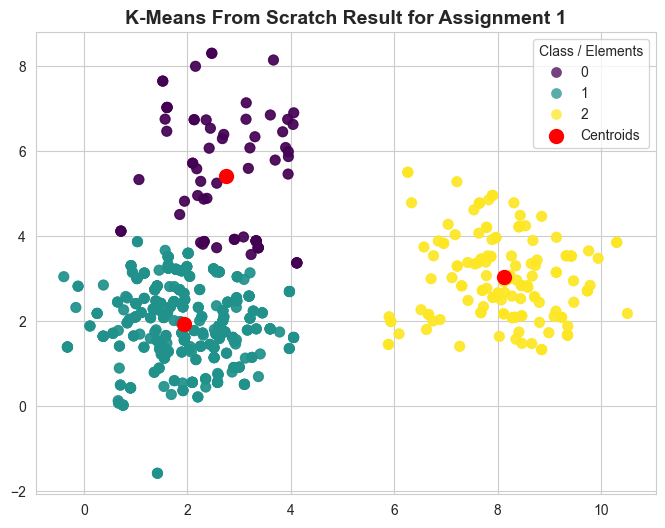

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=data[:, 0], 
    y=data[:, 1], 
    hue=labels, 
    palette="viridis",    # Bảng màu giống như bạn dùng ở matplotlib nhưng mịn hơn
    alpha=0.75, 
    s=60,                 # Tăng kích thước điểm một chút cho dễ nhìn
    edgecolor="none",     # Xóa viền trắng quanh các điểm dữ liệu
    legend="full"
)

plt.scatter(data[:, 0], data[:, 1], c=labels, s=50, cmap='viridis', alpha=0.7)
plt.scatter(model.centroid[:, 0], model.centroid[:, 1], c='red', s=100, label='Centroids')
plt.title("K-Means From Scratch Result for Assignment 1", fontsize=14, fontweight='bold')
plt.grid('--')
plt.legend(title="Class / Elements", loc="upper right", frameon=True)
plt.show()

### Assignment 2 (2 scores):
- Generate a toy dataset having $1200$ points following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

In [ ]:
cov = [[1, 0],
       [0, 1]]
cluster_01 = np.random.multivariate_normal([2, 2], cov, 1200)
cluster_02 = np.random.multivariate_normal([8, 3], cov, 200)
cluster_03 = np.random.multivariate_normal([3, 6], cov, 1000)
data = np.vstack([cluster_01, cluster_02, cluster_03])
data

array([[-0.20469472,  2.92595422],
       [ 2.07598167,  2.98951094],
       [ 0.4492525 ,  1.08321091],
       ...,
       [ 3.41281507,  3.95459263],
       [ 3.00535051,  4.57460137],
       [ 2.38207461,  4.76041643]], shape=(2400, 2))

In [ ]:
model_02 = KMeanClustering()
label_02 = model_02.fit(data)

Converged early at iteration 10


In [ ]:
model_02.centroid

array([[2.02839655, 1.97901133],
       [7.86401025, 2.85220175],
       [2.96926496, 5.72483811]])

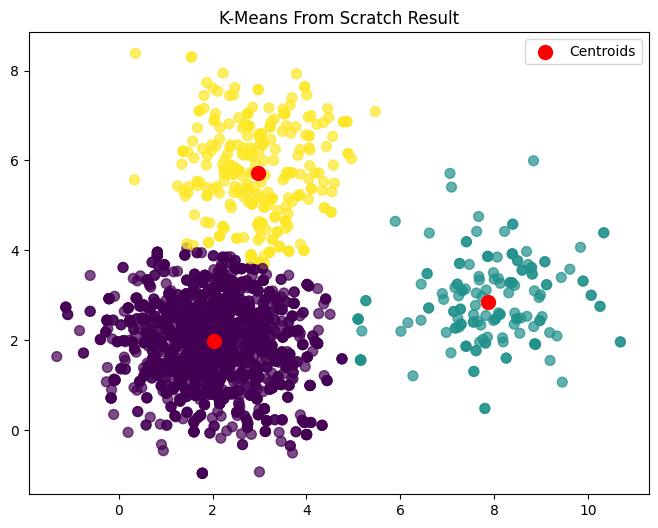

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=label_02, s=50, cmap='viridis', alpha=0.7)
plt.scatter(model_02.centroid[:, 0], model_02.centroid[:, 1], c='red', s=100, label='Centroids')
plt.title("K-Means From Scratch Result")
plt.legend()
plt.show()

### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma_1)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma_2)$ where 

$$
    \Sigma_1 = 
    \left(\begin{array}{cc}
        1 & 0 \\
        0 & 1
    \end{array}\right)
$$ 

and

$$
\Sigma_2 = 
    \left(\begin{array}{cc}
        10 & 0 \\
        0 & 1
    \end{array}\right)
$$.

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

In [ ]:
cov_01 = [[1, 0],
         [0, 1]]
cov_02 = [[10, 0],
          [0, 1]]

cluster_01 = np.random.multivariate_normal([2, 2], cov_01, 200)
cluster_02 = np.random.multivariate_normal([8, 3], cov_01, 200)
cluster_03 = np.random.multivariate_normal([3, 6], cov_02, 200)
data = np.vstack([cluster_01, cluster_02, cluster_03])
data

array([[0.02399023, 0.86271118],
       [2.09714805, 2.30147245],
       [2.76577507, 0.98676835],
       ...,
       [5.86220849, 6.04771921],
       [5.93769976, 7.29011551],
       [2.62343463, 7.73778631]], shape=(600, 2))

In [ ]:
model_03 = KMeanClustering()
label_03 = model_03.fit(data)


Converged early at iteration 17


In [ ]:
model_02.centroid

array([[2.02839655, 1.97901133],
       [7.86401025, 2.85220175],
       [2.96926496, 5.72483811]])

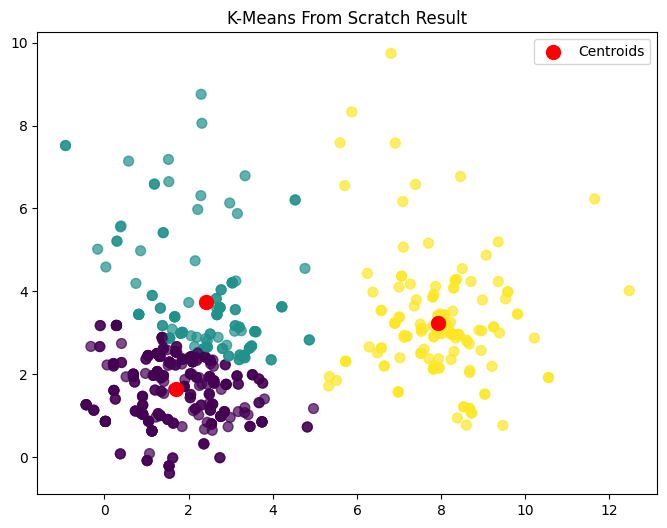

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=label_03, s=50, cmap='viridis', alpha=0.7)
plt.scatter(model_03.centroid[:, 0], model_03.centroid[:, 1], c='red', s=100, label='Centroids')
plt.title("K-Means From Scratch Result")
plt.legend()
plt.show()